# 060 — Validate the adopted infrasound moving-median baseline correction

Notebook 010 now creates the canonical 1.0 s moving-median baseline-corrected
six-channel Stream. This notebook independently recomputes that correction,
verifies the Notebook 010 product, and evaluates whether the adopted window
preserves event timing, waveform morphology, and amplitude measurements.

The canonical product is not rewritten here.


## Processing history and experiments

The event catalogue and pressure-processing strategy evolved through the
following steps.

1. **Manual candidate picking in Antelope's `dbpick` program.** Candidate airwave arrivals
   were picked manually on the BCHH channels. These original pick times are the
   most important legacy observations and were exported from MATLAB/GISMO with
   millisecond precision.
2. **Legacy event catalogues.** Earlier MATLAB workflows produced catalogues of
   153 and 157 events. Their precise start/end times were recovered, but neither
   catalogue was treated automatically as ground truth.
3. **Differential-travel-time association.** pressure-channel picks were reduced
   to a common reference time using reconstructed source-to-sensor distances and a
   wind-assisted acoustic speed. This removed the normal 0.08–0.09 s array
   traversal delay and allowed short-window multi-channel association.
4. **Shifted waveform stacks.** Differentially shifted mean and median stacks
   were generated to assess coherence and improve visibility of weak events.
5. **Butterworth high-pass experiment.** A filter bank from 0.5 to 20 Hz was
   tested. Some filters improved SNR for some events but degraded others and
   altered the apparent compression-rarefaction shape. Filtering is therefore
   not used for physical pressure measurements.
6. **Local linear-baseline experiment.** Baselines fitted to short exterior
   windows often developed steep, implausible trends because too few samples
   controlled the fit.
7. **Moving-median baseline.** Visual review showed that the long-window moving
   median followed the slowly varying baseline more plausibly. This notebook
   adopts that baseline directly for pressure measurements.

A later detection-only workflow may still use a gently filtered waveform as a
guide for very weak arrivals, but reported pressure amplitudes should come from
the unfiltered, response-corrected data after moving-median baseline removal.

The experiment retains the original pulse-measurement and sensitivity
tests while obtaining channel identities, physical units, geometry, reference
sensor, and effective acoustic speed from upstream products.


## 1. Imports and project paths

In [1]:
from pathlib import Path
from collections.abc import Mapping
import json
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import median_filter
from obspy import Stream, Trace, UTCDateTime, read


project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config

ANALYSIS_CONFIG_FILE = config.NB010_DIR / "analysis_configuration.json"
WEATHER_SUMMARY_FILE = config.NB020_DIR / "weather_acoustic_summary.csv"
FINAL_CATALOGUE_FILE = config.NB030_DIR / "final_153_event_catalogue.csv"
PICK_ASSIGNMENT_FILE = config.NB030_DIR / "reduced_time_pick_assignments.csv"
REVIEW_METRICS_FILE = (
    config.NB050_DIR / "final_event_review_metrics.csv"
)

# Optional standardized quality metrics produced by S03. Notebook 050 normally
# carries these columns through into REVIEW_METRICS_FILE, but keeping these
# fallbacks lets Notebook 060 remain robust to a review run made without S03.
S03_QUALITY_CANDIDATES = [
    config.NB040_DIR / "event_waveform_quality.csv",
]

# Optional list produced by the earlier filter-comparison workflow.
SELECTED_FILTER_EVENTS_FILE = (
    config.NB060_DIR / "selected_filter_test_events.csv"
)

OUTPUT_DIR = config.NB060_DIR
EVENT_PLOT_DIR = OUTPUT_DIR / "event_diagnostics"
SUMMARY_PLOT_DIR = OUTPUT_DIR / "summary_figures"
DERIVED_OUTPUT_DIR = OUTPUT_DIR / "derived"

for directory in [
    OUTPUT_DIR,
    EVENT_PLOT_DIR,
    SUMMARY_PLOT_DIR,
    DERIVED_OUTPUT_DIR,
    config.NB010_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Preserve these established filenames because downstream notebooks consume
# them. Their parent directory is supplied by project_config.
BASELINE_REMOVED_PICKLE = (
    config.NB010_DIR
    / "bchh_corrected_moving_median_baseline_removed.pkl"
)
BASELINE_REMOVED_MSEED = (
    config.NB010_DIR
    / "bchh_corrected_moving_median_baseline_removed.mseed"
)

plt.rcParams.update({
    "font.size": 8.5,
    "axes.titlesize": 9.5,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
    "figure.dpi": 120,
})


## 2. Configuration

In [2]:
# Adopted whole-stream moving-median baseline length.
# This is much longer than a typical ~0.05–0.20 s impulsive airwave.
MOVING_MEDIAN_WINDOW_S = 1.0

# Optional windows retained for sensitivity plots on selected events.
MOVING_MEDIAN_TEST_WINDOWS_S = (0.125, 0.25, 0.50, 1.00, 2.00)

MAX_SELECTED_EVENTS = 24

# Event extraction relative to reconstructed reduced time.
EXTRACT_PRE_S = 0.65
EXTRACT_POST_S = 0.75

# Search for the compression-rarefaction pair near the associated event.
SIGNAL_SEARCH_WINDOW_S = (-0.04, 0.25)

# Enforce positive compression first and negative rarefaction later.
MINIMUM_POSITIVE_NEGATIVE_LAG_S = 0.010
MAXIMUM_POSITIVE_NEGATIVE_LAG_S = 0.180

# For an approximately sinusoidal one-cycle signal, A-to-B is half a period.
BOUNDARY_EXTENSION_FRACTION = 0.50

# Optional return-to-noise boundary refinement.
REFINE_BOUNDARIES_TO_NOISE = True
NOISE_WINDOW_S = (-0.40, -0.10)
BOUNDARY_NOISE_MULTIPLIER = 2.0
BOUNDARY_CONSECUTIVE_SAMPLES = 3
MAXIMUM_BOUNDARY_SEARCH_EXTENSION_S = 0.12

WRITE_EVENT_DIAGNOSTIC_PDFS = True


### Why 1.0 s is currently the default

The 1.0 s moving-median window is a **provisional conservative choice**, not a
result already established as optimal.

Most impulsive airwaves considered here occupy roughly 0.05–0.20 s. A baseline
window should be several times longer than the signal so that the median is
controlled mainly by background samples rather than by the pulse itself. A
1.0 s window is therefore approximately 5–20 times longer than a typical event.

The notebook tests 0.125, 0.25, 0.5, 1.0, and 2.0 s windows. The final value should be
chosen from:

- visual baseline quality;
- stability of positive, negative, and peak-to-peak pressure;
- preservation of event duration and impulse;
- minimal absorption of the signal into the estimated baseline;
- absence of excessive smoothing across genuine slow baseline changes.

### Is the moving median causal or zero phase?

The implementation uses a **centered, symmetric moving-median window**:

```python
median_filter(values, size=window_samples, mode="nearest")
```

Each baseline value uses samples from both before and after that time. It is
therefore **noncausal** and suitable for retrospective analysis.

A moving median is nonlinear, so it does not have a conventional frequency
response or phase response and should not technically be called a zero-phase
filter. However, because the window is centered rather than one-sided, it does
not introduce the systematic time delay associated with a causal running
filter. Sample timestamps remain unchanged, but nonlinear baseline subtraction can
change which extrema or threshold crossings are selected as event times.

## 3. Load the response-corrected Stream and event products

In [3]:
for required_file in [
    ANALYSIS_CONFIG_FILE,
    WEATHER_SUMMARY_FILE,
    FINAL_CATALOGUE_FILE,
    PICK_ASSIGNMENT_FILE,
]:
    if not required_file.exists():
        raise FileNotFoundError(f"Required input not found: {required_file}")

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
stream_file = Path(analysis_config["stream_file"]).expanduser()
geometry_file = Path(analysis_config["geometry_file"]).expanduser()

baseline_products = analysis_config.get("baseline_removed_streams", {})
BASELINE_REMOVED_MSEED = Path(
    baseline_products.get(
        "mseed",
        config.NB010_DIR
        / "bchh_corrected_moving_median_baseline_removed.mseed",
    )
).expanduser()
BASELINE_REMOVED_PICKLE = Path(
    baseline_products.get(
        "pickle",
        config.NB010_DIR
        / "bchh_corrected_moving_median_baseline_removed.pkl",
    )
).expanduser()

for required_file in [stream_file, geometry_file]:
    if not required_file.exists():
        raise FileNotFoundError(f"Notebook 010 product not found: {required_file}")

st_corr = read(str(stream_file), format="PICKLE")
if BASELINE_REMOVED_MSEED.exists():
    baseline_product_file = BASELINE_REMOVED_MSEED
    st_corr_median_removed = read(
        str(baseline_product_file), format="MSEED"
    )
elif BASELINE_REMOVED_PICKLE.exists():
    baseline_product_file = BASELINE_REMOVED_PICKLE
    st_corr_median_removed = read(
        str(baseline_product_file), format="PICKLE"
    )
else:
    raise FileNotFoundError(
        "Notebook 010 baseline-corrected Stream not found. "
        f"Expected {BASELINE_REMOVED_MSEED} or {BASELINE_REMOVED_PICKLE}"
    )

bchh_geometry = pd.read_csv(geometry_file)
weather_summary = pd.read_csv(WEATHER_SUMMARY_FILE)
events = pd.read_csv(FINAL_CATALOGUE_FILE)
pick_assignments = pd.read_csv(PICK_ASSIGNMENT_FILE)

if len(weather_summary) != 1:
    raise ValueError(
        "Expected one row in the weather summary; "
        f"found {len(weather_summary)}"
    )

required_event_columns = {
    "final_event_number",
    "reconstructed_event_number",
    "reduced_event_epoch_s",
    "corrected_pick_span_s",
}
missing = required_event_columns.difference(events.columns)
if missing:
    raise KeyError(f"Final catalogue lacks columns: {sorted(missing)}")

if not events["final_event_number"].is_unique or not events["reconstructed_event_number"].is_unique:
    raise ValueError("Catalogue identifiers must be unique")

if REVIEW_METRICS_FILE.exists():
    review_metrics = pd.read_csv(REVIEW_METRICS_FILE)
    merge_keys = [
        key
        for key in ("final_event_number", "reconstructed_event_number")
        if key in review_metrics.columns
    ]
    if not merge_keys:
        raise KeyError(
            "Notebook 050 review metrics lack final/reconstructed event numbers"
        )
    if "final_event_number" not in merge_keys or set(review_metrics["final_event_number"]) != set(events["final_event_number"]):
        raise ValueError("Review metrics must match the final catalogue event IDs")
    review_columns = [
        column
        for column in review_metrics.columns
        if column in merge_keys or column not in events.columns
    ]
    events = events.merge(
        review_metrics[review_columns],
        on=merge_keys,
        how="left",
        validate="one_to_one",
    )
    print("Loaded Notebook 050 review metrics:", REVIEW_METRICS_FILE)
else:
    review_metrics = pd.DataFrame()
    print("Notebook 050 review metrics not found; using catalogue/S03 metrics only")

quality_file = next(
    (path for path in S03_QUALITY_CANDIDATES if path.exists()),
    None,
)
if (
    quality_file is not None
    and "s03_robust_stack_peak_snr" not in events.columns
):
    waveform_quality = pd.read_csv(quality_file)
    if set(waveform_quality["final_event_number"]) != set(events["final_event_number"]):
        raise ValueError("Quality metrics must match the final catalogue event IDs")
    events = events.merge(
        waveform_quality,
        on="final_event_number",
        how="left",
        validate="one_to_one",
    )
    print("Loaded S03 quality metrics:", quality_file)
else:
    waveform_quality = pd.DataFrame()

associated_assignments = pick_assignments.loc[
    pick_assignments["association_status"].eq("associated")
].copy()
support = (
    associated_assignments
    .groupby("reconstructed_event_number")
    .agg(
        assigned_pick_count=("pickIndex", "size"),
        assigned_channel_count=("association_channel", "nunique"),
    )
    .reset_index()
)
events = events.merge(
    support,
    on="reconstructed_event_number",
    how="left",
    validate="one_to_one",
)

stream_channels = [trace.stats.channel for trace in st_corr]
if len(stream_channels) != len(set(stream_channels)):
    raise ValueError(
        "Corrected Stream contains duplicate channel codes: "
        f"{stream_channels}"
    )

def normalized_units(value: object) -> str:
    return str(value).strip().lower().replace(" ", "")


stream_units = {
    trace.stats.channel: normalized_units(trace.stats.get("units"))
    for trace in st_corr
}
INFRASOUND_CHANNELS = tuple(sorted(
    channel
    for channel in stream_channels
    if stream_units[channel] in {"pa", "pascal", "pascals"}
))
component_order = {"Z": 0, "N": 1, "E": 2}
SEISMIC_CHANNELS = tuple(sorted(
    (
        channel
        for channel in stream_channels
        if stream_units[channel] in {"m/s", "m/s**1", "m*s^-1"}
    ),
    key=lambda channel: (
        component_order.get(channel[-1].upper(), 99),
        channel,
    ),
))
if not INFRASOUND_CHANNELS:
    raise ValueError("No pressure channels were found in the corrected Stream")

REFERENCE_CHANNEL = str(
    analysis_config["infrasound_reference_channel"]
)
if REFERENCE_CHANNEL not in INFRASOUND_CHANNELS:
    raise ValueError(
        f"Configured reference {REFERENCE_CHANNEL!r} is not a pressure channel"
    )

geometry_by_channel = (
    bchh_geometry
    .drop_duplicates("channel")
    .set_index("channel")
)
BCHH_INFRASOUND_DISTANCES_M = {
    channel: float(geometry_by_channel.at[channel, "distance_m"])
    for channel in INFRASOUND_CHANNELS
}
WIND_CORRECTED_ACOUSTIC_SPEED_MPS = float(
    weather_summary.iloc[0]["effective_sound_speed_mps"]
)

events["reduced_event_time"] = pd.to_datetime(
    events["reduced_event_epoch_s"],
    unit="s",
    utc=True,
)

if SELECTED_FILTER_EVENTS_FILE.exists():
    previously_selected_events = pd.read_csv(
        SELECTED_FILTER_EVENTS_FILE
    )
else:
    previously_selected_events = pd.DataFrame()

print("Raw response-corrected Stream:", stream_file)
print("Canonical Notebook 010 baseline product:", baseline_product_file)
print("Pressure channels:", INFRASOUND_CHANNELS)
print("Seismic channels:", SEISMIC_CHANNELS)
print(
    "Effective acoustic speed:",
    f"{WIND_CORRECTED_ACOUSTIC_SPEED_MPS:.3f} m/s",
)
print(f"Final catalogue events: {len(events)}")


Loaded Notebook 050 review metrics: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/050_review_event_catalogue_waveforms/final_event_review_metrics.csv
Raw response-corrected Stream: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/bchh_corrected_analysis_window.pkl
Canonical Notebook 010 baseline product: /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/bchh_corrected_moving_median_baseline_removed.mseed
Pressure channels: ('DD1', 'DD2', 'DD3')
Seismic channels: ('DHZ', 'DHN', 'DHE')
Effective acoustic speed: 350.977 m/s
Final catalogue events: 153


## 4. Moving-median implementation

In [4]:
def odd_sample_count(
    duration_s: float,
    sampling_rate_hz: float,
) -> int:
    count = max(
        3,
        int(round(duration_s * sampling_rate_hz)),
    )
    if count % 2 == 0:
        count += 1
    return count


def moving_median_baseline(
    values: np.ndarray,
    *,
    sampling_rate_hz: float,
    window_s: float,
) -> np.ndarray:
    """
    Estimate a slowly varying baseline with a centered moving median.

    scipy.ndimage.median_filter is used because it is substantially faster
    than a pandas rolling median for the full 33-minute, 250-Hz stream.
    """
    values = np.asarray(values, dtype=float)
    window_samples = odd_sample_count(
        window_s,
        sampling_rate_hz,
    )

    return median_filter(
        values,
        size=window_samples,
        mode="nearest",
    )


def remove_moving_median_baseline(
    trace: Trace,
    *,
    window_s: float,
) -> tuple[Trace, np.ndarray]:
    corrected = trace.copy()
    baseline = moving_median_baseline(
        corrected.data,
        sampling_rate_hz=float(
            corrected.stats.sampling_rate
        ),
        window_s=window_s,
    )
    corrected.data = (
        corrected.data.astype(float) - baseline
    )
    corrected.stats.processing = list(
        getattr(corrected.stats, "processing", [])
    )
    corrected.stats.processing.append(
        "moving-median baseline removed: "
        f"window={window_s:g} s"
    )
    return corrected, baseline

## 5. Independently recompute the adopted correction and verify Notebook 010

The same centered 1.0 s moving median is recomputed from the response-corrected
Notebook 010 Stream. The result is compared channel-by-channel with the
canonical Notebook 010 baseline-corrected product. This makes Notebook 060 a
validation step rather than a producer of a downstream dependency.


In [5]:
st_corr_median_recomputed = Stream()
whole_stream_baselines = {}

for trace in st_corr:
    if trace.stats.channel in INFRASOUND_CHANNELS:
        corrected_trace, baseline = remove_moving_median_baseline(
            trace,
            window_s=MOVING_MEDIAN_WINDOW_S,
        )
        st_corr_median_recomputed += corrected_trace
        whole_stream_baselines[trace.id] = baseline
    else:
        st_corr_median_recomputed += trace.copy()

st_corr_median_recomputed.sort(keys=["channel"])
st_corr_median_removed.sort(keys=["channel"])

verification_rows = []
for channel in [tr.stats.channel for tr in st_corr_median_recomputed]:
    recomputed_matches = st_corr_median_recomputed.select(channel=channel)
    canonical_matches = st_corr_median_removed.select(channel=channel)
    if len(recomputed_matches) != 1 or len(canonical_matches) != 1:
        raise ValueError(
            f"Expected one recomputed and one canonical trace for {channel}"
        )
    recomputed = recomputed_matches[0]
    canonical = canonical_matches[0]

    if recomputed.stats.npts != canonical.stats.npts:
        raise ValueError(
            f"Sample-count mismatch for {channel}: "
            f"{recomputed.stats.npts} vs {canonical.stats.npts}"
        )
    if abs(float(recomputed.stats.starttime - canonical.stats.starttime)) > 1e-9:
        raise ValueError(f"Start-time mismatch for {channel}")
    if float(recomputed.stats.sampling_rate) != float(canonical.stats.sampling_rate):
        raise ValueError(f"Sampling-rate mismatch for {channel}")

    difference = (
        np.asarray(recomputed.data, dtype=float)
        - np.asarray(canonical.data, dtype=float)
    )
    max_abs_difference = float(np.max(np.abs(difference)))
    scale = float(np.max(np.abs(recomputed.data)))
    if not np.isfinite(recomputed.data).all() or not np.isfinite(canonical.data).all():
        raise ValueError(f"Nonfinite samples for {channel}")
    # Portable FLOAT64 output should preserve the canonical correction.
    tolerance = 1e-12 * max(scale, 1e-12) if channel in INFRASOUND_CHANNELS else 0.0
    verification_rows.append({
        "channel": channel,
        "max_abs_difference": max_abs_difference,
        "tolerance": tolerance,
        "exact_sample_match": bool(np.array_equal(recomputed.data, canonical.data)),
        "passes": max_abs_difference <= tolerance,
    })

baseline_product_verification = pd.DataFrame(verification_rows)
display(baseline_product_verification)

if not baseline_product_verification["passes"].all():
    raise RuntimeError(
        "The canonical Notebook 010 baseline product does not match "
        "the correction independently recomputed in Notebook 060"
    )

print("Notebook 010 baseline product verified.")


,channel,max_abs_difference,tolerance,exact_sample_match,passes
0,DD1,0.0,1.301957e-09,True,True
1,DD2,0.0,1.507523e-09,True,True
2,DD3,0.0,1.385598e-09,True,True
3,DHE,0.0,0.000000e+00,True,True
4,DHN,0.0,0.000000e+00,True,True
5,DHZ,0.0,0.000000e+00,True,True


Notebook 010 baseline product verified.


## 6. Record baseline-product verification


In [6]:
verification_file = (
    DERIVED_OUTPUT_DIR / "baseline_product_verification.csv"
)
baseline_product_verification.to_csv(
    verification_file,
    index=False,
)

verification_metadata_file = (
    DERIVED_OUTPUT_DIR / "baseline_product_verification.json"
)
verification_metadata = {
    "canonical_product": str(baseline_product_file),
    "raw_stream": str(stream_file),
    "moving_median_window_s": MOVING_MEDIAN_WINDOW_S,
    "median_kernel_samples": {tr.stats.channel: odd_sample_count(MOVING_MEDIAN_WINDOW_S, tr.stats.sampling_rate) for tr in st_corr if tr.stats.channel in INFRASOUND_CHANNELS},
    "edge_mode": "nearest",
    "pressure_channels": list(INFRASOUND_CHANNELS),
    "seismic_channels_unchanged": list(SEISMIC_CHANNELS),
    "all_channels_pass": bool(
        baseline_product_verification["passes"].all()
    ),
}
verification_metadata_file.write_text(
    json.dumps(verification_metadata, indent=2) + "\n"
)

print("Wrote", verification_file)
print("Wrote", verification_metadata_file)


Wrote /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/060_validate_infrasound_baseline_correction/derived/baseline_product_verification.csv
Wrote /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/060_validate_infrasound_baseline_correction/derived/baseline_product_verification.json


## 7. Visualize the complete baseline-removed Stream

In [7]:
WHOLE_STREAM_FIGURE = (
    SUMMARY_PLOT_DIR
    / "whole_stream_moving_median_baseline_removed.pdf"
)

figure = st_corr_median_removed.plot(
    equal_scale=False,
    show=False,
    size=(1400, 1000),
)
figure.savefig(
    WHOLE_STREAM_FIGURE,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print(f"Wrote {WHOLE_STREAM_FIGURE}")

Wrote /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/060_validate_infrasound_baseline_correction/summary_figures/whole_stream_moving_median_baseline_removed.pdf


## 8. Compare the full raw and corrected infrasound traces

This overview is intentionally decimated for plotting only. All calculations
and saved waveform files retain the original 250-Hz samples.

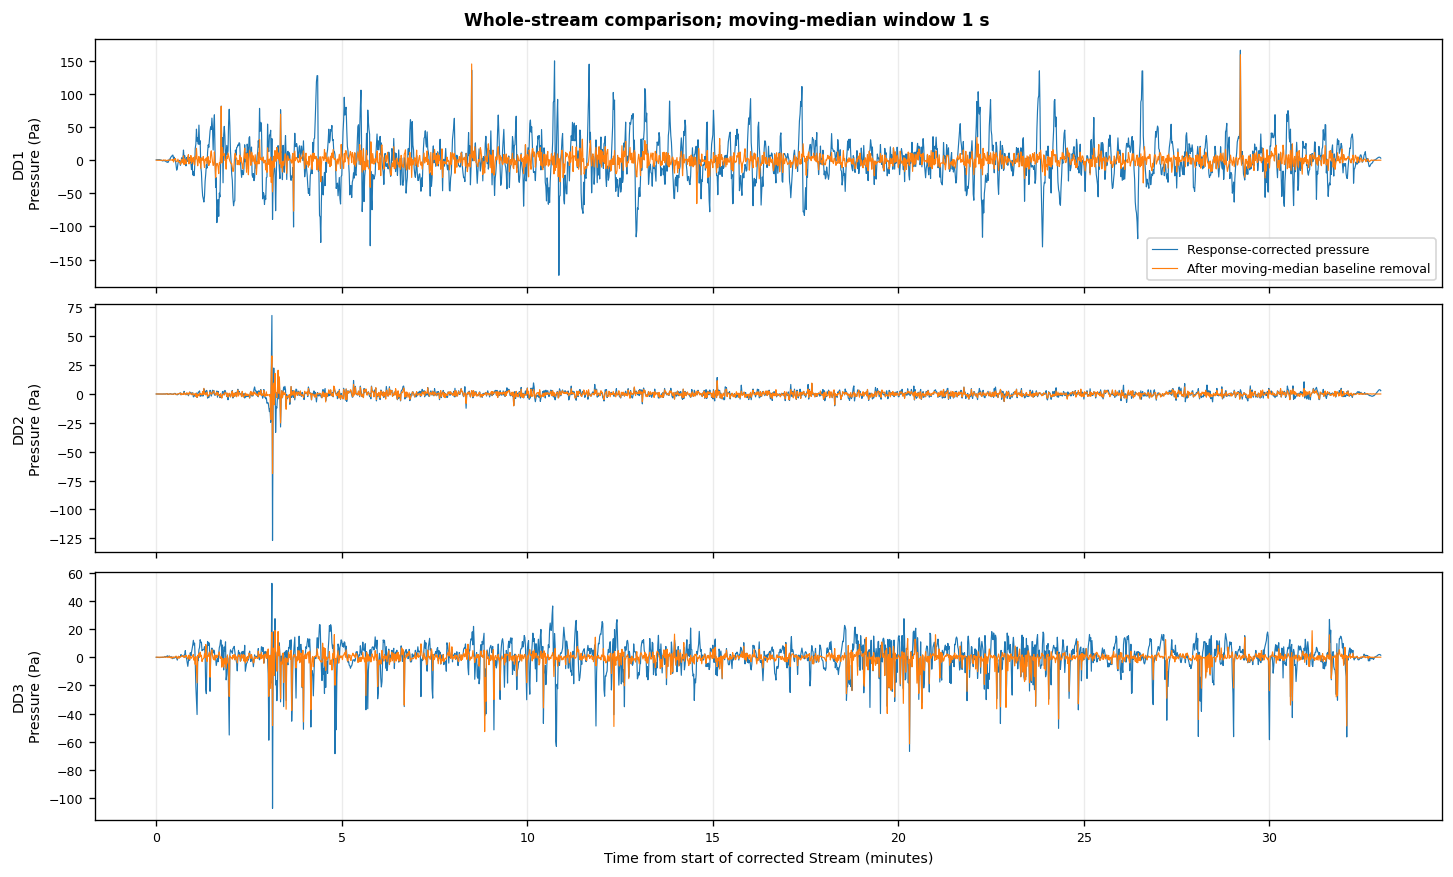

In [8]:
fig, axes = plt.subplots(
    len(INFRASOUND_CHANNELS),
    1,
    figsize=(12.0, 7.2),
    sharex=True,
    constrained_layout=True,
)

for axis, channel in zip(axes, INFRASOUND_CHANNELS):
    raw = st_corr.select(channel=channel)[0]
    corrected = st_corr_median_removed.select(
        channel=channel
    )[0]

    decimation = max(
        1,
        int(round(raw.stats.sampling_rate))
    )

    relative_minutes = (
        raw.times()[::decimation] / 60.0
    )

    axis.plot(
        relative_minutes,
        raw.data[::decimation],
        linewidth=0.7,
        label="Response-corrected pressure",
    )
    axis.plot(
        relative_minutes,
        corrected.data[::decimation],
        linewidth=0.7,
        label="After moving-median baseline removal",
    )
    axis.set_ylabel(f"{channel}\nPressure (Pa)")
    axis.grid(True, axis="x", alpha=0.25)

axes[0].legend()
axes[-1].set_xlabel(
    "Time from start of corrected Stream (minutes)"
)
fig.suptitle(
    f"Whole-stream comparison; moving-median window "
    f"{MOVING_MEDIAN_WINDOW_S:g} s",
    fontweight="bold",
)

comparison_path = (
    SUMMARY_PLOT_DIR
    / "whole_stream_raw_vs_baseline_removed.pdf"
)
fig.savefig(
    comparison_path,
    dpi=220,
    bbox_inches="tight",
)
plt.show()

## 9. Select the clearest events for detailed review

In [9]:
# Select a representative subset for detailed visual/sensitivity review.
# Prefer the explicit S02 subset when it can be mapped to the final catalogue;
# otherwise use all three-channel final events.

if not previously_selected_events.empty:
    if "final_event_number" in previously_selected_events.columns:
        candidate_numbers = set(
            previously_selected_events["final_event_number"].astype(int)
        )
        selection_pool = events.loc[
            events["final_event_number"].isin(candidate_numbers)
        ].copy()
    elif "reconstructed_event_number" in previously_selected_events.columns:
        candidate_numbers = set(
            previously_selected_events["reconstructed_event_number"].astype(int)
        )
        selection_pool = events.loc[
            events["reconstructed_event_number"].isin(candidate_numbers)
        ].copy()
    else:
        selection_pool = events.copy()
else:
    selection_pool = events.loc[
        events["assigned_channel_count"].fillna(0).ge(3)
    ].copy()

# Current quality ranking. S03 supplies the standardized robust stack SNR;
# Notebook 050 supplies an aligned response-corrected stack amplitude. Both are
# optional, so the ranking degrades gracefully if either product is absent.
if "s03_robust_stack_peak_snr" in selection_pool.columns:
    selection_pool["selection_snr"] = pd.to_numeric(
        selection_pool["s03_robust_stack_peak_snr"], errors="coerce"
    )
else:
    selection_pool["selection_snr"] = np.nan

if "median_stack_peak_absolute_pa" in selection_pool.columns:
    selection_pool["selection_amplitude_pa"] = pd.to_numeric(
        selection_pool["median_stack_peak_absolute_pa"], errors="coerce"
    )
else:
    selection_pool["selection_amplitude_pa"] = np.nan

def descending_rank_or_neutral(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().any():
        ranked = numeric.rank(ascending=False, method="min")
        return ranked.fillna(ranked.max() + 1.0)
    return pd.Series(
        np.ones(len(series), dtype=float),
        index=series.index,
    )

selection_pool["rank_snr"] = descending_rank_or_neutral(
    selection_pool["selection_snr"]
)
selection_pool["rank_amplitude"] = descending_rank_or_neutral(
    selection_pool["selection_amplitude_pa"]
)
selection_pool["rank_pick_span"] = (
    pd.to_numeric(
        selection_pool["corrected_pick_span_s"], errors="coerce"
    )
    .rank(ascending=True, method="min")
)
selection_pool["rank_pick_span"] = selection_pool[
    "rank_pick_span"
].fillna(selection_pool["rank_pick_span"].max() + 1.0)

selection_pool["review_rank_score"] = (
    0.45 * selection_pool["rank_snr"]
    + 0.35 * selection_pool["rank_amplitude"]
    + 0.20 * selection_pool["rank_pick_span"]
)

# Lower rank scores are better. The old notebook used tail(), which selected
# the worst-ranked rows; use head() here.
selected_events = (
    selection_pool
    .sort_values(
        ["review_rank_score", "final_event_number"]
    )
    .head(MAX_SELECTED_EVENTS)
    .reset_index(drop=True)
)

display_columns = [
    "final_event_number",
    "reconstructed_event_number",
    "channels",
    "corrected_pick_span_s",
    "selection_snr",
    "selection_amplitude_pa",
    "review_rank_score",
]
display(selected_events[display_columns])

selected_events.to_csv(
    DERIVED_OUTPUT_DIR
    / "selected_moving_median_review_events.csv",
    index=False,
)


,final_event_number,reconstructed_event_number,channels,corrected_pick_span_s,selection_snr,selection_amplitude_pa,review_rank_score
0,24,24,"DD1,DD2,DD3",0.002107,67.526877,258.539847,4.90
1,13,13,"DD1,DD2,DD3",0.002107,38.886054,1385.592372,5.40
2,22,22,"DD1,DD2,DD3",0.003856,118.527791,260.065767,7.00
3,18,18,"DD1,DD2,DD3",0.002107,31.628236,192.558784,8.85
4,75,75,"DD1,DD2,DD3",0.001770,42.834158,55.645493,10.25
5,56,56,"DD1,DD2,DD3",0.004097,48.060917,109.256516,10.60
6,54,54,"DD1,DD2,DD3",0.006107,86.500969,135.492642,11.50
7,57,57,"DD1,DD2,DD3",0.004867,71.032670,78.241081,12.65
8,25,25,"DD1,DD2,DD3",0.004866,42.421277,96.984959,13.60
9,83,83,"DD1,DD2,DD3",0.002760,38.021816,44.322189,15.90


## 10. Differential travel-time helpers

In [10]:
def differential_delays_s(
    distances_m: Mapping[str, float],
    *,
    effective_speed_mps: float,
    reference_channel: str,
) -> dict[str, float]:
    reference_distance_m = distances_m[reference_channel]
    return {
        channel: (
            distance_m - reference_distance_m
        ) / effective_speed_mps
        for channel, distance_m in distances_m.items()
    }


DIFFERENTIAL_DELAYS_S = differential_delays_s(
    BCHH_INFRASOUND_DISTANCES_M,
    effective_speed_mps=WIND_CORRECTED_ACOUSTIC_SPEED_MPS,
    reference_channel=REFERENCE_CHANNEL,
)


def select_one_trace(
    stream: Stream,
    channel: str,
) -> Trace:
    matches = stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(
            f"Expected one {channel} trace; found {len(matches)}"
        )
    return matches[0]


def shift_trace_to_reference(
    trace: Trace,
    delay_s: float,
) -> Trace:
    shifted = trace.copy()
    shifted.stats.starttime -= delay_s
    return shifted

## 11. Extract shifted raw and baseline-removed event arrays

In [11]:
def extract_shifted_event_arrays(
    event_epoch_s: float,
    *,
    stream: Stream,
) -> tuple[np.ndarray, dict[str, np.ndarray], float]:
    shifted_traces = {}

    for channel in INFRASOUND_CHANNELS:
        trace = select_one_trace(
            stream,
            channel,
        ).copy()
        trace = shift_trace_to_reference(
            trace,
            DIFFERENTIAL_DELAYS_S[channel],
        )
        trace.trim(
            UTCDateTime(event_epoch_s - EXTRACT_PRE_S),
            UTCDateTime(event_epoch_s + EXTRACT_POST_S),
            pad=False,
        )
        shifted_traces[channel] = trace

    sampling_rates = {
        float(trace.stats.sampling_rate)
        for trace in shifted_traces.values()
    }
    if len(sampling_rates) != 1:
        raise ValueError(
            "Infrasound traces have inconsistent sample rates"
        )
    sampling_rate_hz = sampling_rates.pop()

    common_start_s = max(
        float(trace.stats.starttime.timestamp)
        for trace in shifted_traces.values()
    )
    common_end_s = min(
        float(trace.stats.endtime.timestamp)
        for trace in shifted_traces.values()
    )

    sample_count = int(
        np.floor(
            (common_end_s - common_start_s)
            * sampling_rate_hz
        )
    ) + 1

    epoch_grid_s = (
        common_start_s
        + np.arange(sample_count) / sampling_rate_hz
    )
    relative_time_s = epoch_grid_s - event_epoch_s

    arrays = {}

    for channel, trace in shifted_traces.items():
        trace_times_s = (
            float(trace.stats.starttime.timestamp)
            + np.arange(trace.stats.npts)
            / sampling_rate_hz
        )
        arrays[channel] = np.interp(
            epoch_grid_s,
            trace_times_s,
            trace.data.astype(float),
        )

    return relative_time_s, arrays, sampling_rate_hz

## 12. Positive-compression/negative-rarefaction measurement

In [12]:
def robust_noise_scale(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    center = np.nanmedian(values)
    mad = np.nanmedian(np.abs(values - center))
    return 1.4826 * mad


def find_positive_negative_pair(
    values: np.ndarray,
    times_s: np.ndarray,
    *,
    search_window_s: tuple[float, float],
    minimum_lag_s: float,
    maximum_lag_s: float,
) -> dict:
    indices = np.flatnonzero(
        (times_s >= search_window_s[0])
        & (times_s <= search_window_s[1])
    )

    best = None

    for positive_index in indices:
        positive_value = values[positive_index]

        if (
            not np.isfinite(positive_value)
            or positive_value <= 0
        ):
            continue

        positive_time_s = times_s[positive_index]

        negative_candidates = indices[
            (
                times_s[indices]
                >= positive_time_s + minimum_lag_s
            )
            & (
                times_s[indices]
                <= positive_time_s + maximum_lag_s
            )
        ]

        if len(negative_candidates) == 0:
            continue

        negative_index = negative_candidates[
            np.nanargmin(values[negative_candidates])
        ]
        negative_value = values[negative_index]

        if (
            not np.isfinite(negative_value)
            or negative_value >= 0
        ):
            continue

        peak_to_peak = positive_value - negative_value

        if (
            best is None
            or peak_to_peak > best["peak_to_peak_pa"]
        ):
            best = {
                "valid_pair": True,
                "positive_index": int(positive_index),
                "negative_index": int(negative_index),
                "positive_time_s": float(positive_time_s),
                "negative_time_s": float(
                    times_s[negative_index]
                ),
                "positive_peak_pa": float(positive_value),
                "negative_peak_pa": float(negative_value),
                "peak_to_peak_pa": float(peak_to_peak),
                "positive_negative_lag_s": float(
                    times_s[negative_index]
                    - positive_time_s
                ),
            }

    if best is None:
        return {
            "valid_pair": False,
            "positive_index": np.nan,
            "negative_index": np.nan,
            "positive_time_s": np.nan,
            "negative_time_s": np.nan,
            "positive_peak_pa": np.nan,
            "negative_peak_pa": np.nan,
            "peak_to_peak_pa": np.nan,
            "positive_negative_lag_s": np.nan,
        }

    return best

## 13. Estimate event boundaries and impulse

In [13]:
def consecutive_true_run_start(
    condition: np.ndarray,
    run_length: int,
) -> int | None:
    if len(condition) < run_length:
        return None

    convolution = np.convolve(
        condition.astype(int),
        np.ones(run_length, dtype=int),
        mode="valid",
    )
    matches = np.flatnonzero(
        convolution == run_length
    )
    return int(matches[0]) if len(matches) else None


def event_boundaries_from_pair(
    corrected_values: np.ndarray,
    times_s: np.ndarray,
    pair: dict,
) -> dict:
    lag_s = pair["positive_negative_lag_s"]

    sinusoidal_start_s = (
        pair["positive_time_s"]
        - BOUNDARY_EXTENSION_FRACTION * lag_s
    )
    sinusoidal_end_s = (
        pair["negative_time_s"]
        + BOUNDARY_EXTENSION_FRACTION * lag_s
    )

    noise_mask = (
        (times_s >= NOISE_WINDOW_S[0])
        & (times_s <= NOISE_WINDOW_S[1])
    )
    noise_scale_pa = robust_noise_scale(
        corrected_values[noise_mask]
    )
    threshold_pa = (
        BOUNDARY_NOISE_MULTIPLIER * noise_scale_pa
    )

    event_start_s = sinusoidal_start_s
    event_end_s = sinusoidal_end_s
    start_method = "sinusoidal"
    end_method = "sinusoidal"

    if REFINE_BOUNDARIES_TO_NOISE:
        positive_index = int(pair["positive_index"])
        negative_index = int(pair["negative_index"])

        backward_indices = np.flatnonzero(
            (
                times_s
                >= sinusoidal_start_s
                - MAXIMUM_BOUNDARY_SEARCH_EXTENSION_S
            )
            & (
                np.arange(len(times_s))
                < positive_index
            )
        )

        if len(backward_indices):
            reversed_indices = backward_indices[::-1]
            below = (
                np.abs(
                    corrected_values[reversed_indices]
                )
                <= threshold_pa
            )
            run_start = consecutive_true_run_start(
                below,
                BOUNDARY_CONSECUTIVE_SAMPLES,
            )
            if run_start is not None:
                chosen = reversed_indices[
                    run_start
                    + BOUNDARY_CONSECUTIVE_SAMPLES
                    - 1
                ]
                event_start_s = float(times_s[chosen])
                start_method = "noise_return"

        forward_indices = np.flatnonzero(
            (
                np.arange(len(times_s))
                > negative_index
            )
            & (
                times_s
                <= sinusoidal_end_s
                + MAXIMUM_BOUNDARY_SEARCH_EXTENSION_S
            )
        )

        if len(forward_indices):
            below = (
                np.abs(
                    corrected_values[forward_indices]
                )
                <= threshold_pa
            )
            run_start = consecutive_true_run_start(
                below,
                BOUNDARY_CONSECUTIVE_SAMPLES,
            )
            if run_start is not None:
                chosen = forward_indices[run_start]
                event_end_s = float(times_s[chosen])
                end_method = "noise_return"

    return {
        "sinusoidal_start_s": sinusoidal_start_s,
        "sinusoidal_end_s": sinusoidal_end_s,
        "event_start_s": event_start_s,
        "event_end_s": event_end_s,
        "event_duration_s": event_end_s - event_start_s,
        "start_boundary_method": start_method,
        "end_boundary_method": end_method,
        "noise_scale_pa": noise_scale_pa,
        "boundary_threshold_pa": threshold_pa,
    }


def integrate_measurements(
    corrected_values: np.ndarray,
    times_s: np.ndarray,
    boundaries: dict,
) -> dict:
    mask = (
        (times_s >= boundaries["event_start_s"])
        & (times_s <= boundaries["event_end_s"])
    )

    if np.count_nonzero(mask) < 2:
        return {
            "pressure_impulse_pa_s": np.nan,
            "positive_impulse_pa_s": np.nan,
            "negative_impulse_pa_s": np.nan,
        }

    event_values = corrected_values[mask]
    event_times = times_s[mask]

    return {
        "pressure_impulse_pa_s": float(
            np.trapezoid(
                event_values,
                event_times,
            )
        ),
        "positive_impulse_pa_s": float(
            np.trapezoid(
                np.clip(event_values, 0, None),
                event_times,
            )
        ),
        "negative_impulse_pa_s": float(
            np.trapezoid(
                np.clip(event_values, None, 0),
                event_times,
            )
        ),
    }

## 14. Measure events relative to the moving-median baseline

In [14]:
def measure_moving_median_event(
    corrected_values: np.ndarray,
    times_s: np.ndarray,
) -> dict:
    pair = find_positive_negative_pair(
        corrected_values,
        times_s,
        search_window_s=SIGNAL_SEARCH_WINDOW_S,
        minimum_lag_s=(
            MINIMUM_POSITIVE_NEGATIVE_LAG_S
        ),
        maximum_lag_s=(
            MAXIMUM_POSITIVE_NEGATIVE_LAG_S
        ),
    )

    if not pair["valid_pair"]:
        return {
            "valid_measurement": False,
            "failure_reason": (
                "no positive-before-negative pair "
                "within allowed lag"
            ),
        }

    boundaries = event_boundaries_from_pair(
        corrected_values,
        times_s,
        pair,
    )
    impulses = integrate_measurements(
        corrected_values,
        times_s,
        boundaries,
    )

    return {
        "valid_measurement": True,
        "failure_reason": "",
        **pair,
        **boundaries,
        **impulses,
    }

## 15. Run measurements for selected events and channels

In [15]:
measurement_rows = []
measurement_cache = {}

for event in selected_events.itertuples(index=False):
    event_number = int(
        event.reconstructed_event_number
    )
    event_epoch_s = float(
        event.reduced_event_epoch_s
    )

    raw_times_s, raw_arrays, sampling_rate_hz = (
        extract_shifted_event_arrays(
            event_epoch_s,
            stream=st_corr,
        )
    )
    corrected_times_s, corrected_arrays, _ = (
        extract_shifted_event_arrays(
            event_epoch_s,
            stream=st_corr_median_removed,
        )
    )

    if not np.allclose(
        raw_times_s,
        corrected_times_s,
    ):
        raise ValueError(
            "Raw and corrected event grids differ"
        )

    raw_matrix = np.vstack([
        raw_arrays[channel]
        for channel in INFRASOUND_CHANNELS
    ])
    corrected_matrix = np.vstack([
        corrected_arrays[channel]
        for channel in INFRASOUND_CHANNELS
    ])

    raw_with_stack = {
        **raw_arrays,
        "median_stack": np.nanmedian(
            raw_matrix,
            axis=0,
        ),
    }
    corrected_with_stack = {
        **corrected_arrays,
        "median_stack": np.nanmedian(
            corrected_matrix,
            axis=0,
        ),
    }

    for waveform_type in [
        *INFRASOUND_CHANNELS,
        "median_stack",
    ]:
        result = measure_moving_median_event(
            corrected_with_stack[waveform_type],
            corrected_times_s,
        )

        measurement_rows.append({
            "reconstructed_event_number": event_number,
            "waveform_type": waveform_type,
            "moving_median_window_s": (
                MOVING_MEDIAN_WINDOW_S
            ),
            **result,
        })

        measurement_cache[
            (event_number, waveform_type)
        ] = {
            "times_s": corrected_times_s,
            "raw_values": raw_with_stack[
                waveform_type
            ],
            "corrected_values": corrected_with_stack[
                waveform_type
            ],
            **result,
        }

moving_median_measurements = pd.DataFrame(
    measurement_rows
)

moving_median_measurements.to_csv(
    DERIVED_OUTPUT_DIR
    / "moving_median_event_measurements.csv",
    index=False,
)

display(
    moving_median_measurements[
        "valid_measurement"
    ].value_counts()
)

valid_measurement
True     92
False     4
Name: count, dtype: int64

## Direct raw-versus-baseline-corrected event comparison

These figures are intentionally simpler than the measurement diagnostics.
Each channel and the median stack show the original response-corrected
waveform and the moving-median-corrected waveform on the same axes. This
makes it easy to judge whether baseline removal makes the arrival cleaner
without changing its timing or short-period shape.

In [16]:
def build_raw_corrected_comparison_figure(
    event_number: int,
):
    waveform_types = [
        *INFRASOUND_CHANNELS,
        "median_stack",
    ]

    fig, axes = plt.subplots(
        len(waveform_types),
        1,
        figsize=(10.5, 8.3),
        sharex=True,
        constrained_layout=True,
    )

    for axis, waveform_type in zip(
        axes,
        waveform_types,
    ):
        cached = measurement_cache[
            (event_number, waveform_type)
        ]
        times_s = cached["times_s"]
        raw = cached["raw_values"]
        corrected = cached["corrected_values"]

        axis.plot(
            times_s,
            raw,
            linewidth=0.95,
            alpha=0.80,
            label="Raw response-corrected pressure",
        )
        axis.plot(
            times_s,
            corrected,
            linewidth=1.05,
            label="Moving-median baseline removed",
        )
        axis.axhline(
            0.0,
            linewidth=0.55,
            alpha=0.55,
        )
        axis.axvline(
            0.0,
            linewidth=0.7,
            alpha=0.7,
        )
        axis.text(
            0.015,
            0.86,
            waveform_type,
            transform=axis.transAxes,
            fontweight="bold",
            va="top",
        )
        axis.grid(
            True,
            axis="x",
            alpha=0.25,
        )

        if cached["valid_measurement"]:
            axis.axvspan(
                cached["event_start_s"],
                cached["event_end_s"],
                alpha=0.07,
            )
            axis.scatter(
                [cached["positive_time_s"]],
                [cached["positive_peak_pa"]],
                s=46,
                zorder=6,
            )
            axis.scatter(
                [cached["negative_time_s"]],
                [cached["negative_peak_pa"]],
                s=46,
                zorder=6,
            )

    axes[0].legend(
        loc="upper left",
        bbox_to_anchor=(0.0, 1.25),
        ncol=2,
        frameon=False,
    )
    axes[len(INFRASOUND_CHANNELS) // 2].set_ylabel("Pressure (Pa)")
    axes[-1].set_xlabel(
        "Reduced time relative to event (s)"
    )

    event_row = selected_events.loc[
        selected_events[
            "reconstructed_event_number"
        ] == event_number
    ].iloc[0]

    fig.suptitle(
        f"Reconstructed event {event_number:03d}: "
        f"raw versus moving-median-corrected pressure\n"
        f"window {MOVING_MEDIAN_WINDOW_S:g} s; "
        f"initial median-stack SNR "
        f"{event_row['selection_snr']:.1f}",
        fontweight="bold",
    )

    return fig

### Generate raw-versus-corrected comparison PDFs

In [17]:
RAW_CORRECTED_COMPARISON_DIR = (
    OUTPUT_DIR / "raw_vs_corrected"
)
RAW_CORRECTED_COMPARISON_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

for index, event_number in enumerate(
    selected_events[
        "reconstructed_event_number"
    ].astype(int),
    start=1,
):
    figure = build_raw_corrected_comparison_figure(
        event_number
    )
    outfile = (
        RAW_CORRECTED_COMPARISON_DIR
        / f"event_{event_number:03d}_raw_vs_corrected.pdf"
    )
    figure.savefig(
        outfile,
        dpi=220,
        bbox_inches="tight",
    )
    plt.close(figure)

    if (
        index == 1
        or index % 5 == 0
        or index == len(selected_events)
    ):
        print(
            f"Generated {index} of "
            f"{len(selected_events)} comparison figures"
        )

Generated 1 of 24 comparison figures
Generated 5 of 24 comparison figures
Generated 10 of 24 comparison figures
Generated 15 of 24 comparison figures
Generated 20 of 24 comparison figures
Generated 24 of 24 comparison figures


### Preview one raw-versus-corrected comparison

In [18]:
'''preview_comparison = (
    build_raw_corrected_comparison_figure(
        20
    )
)
plt.show()'''

'preview_comparison = (\n    build_raw_corrected_comparison_figure(\n        20\n    )\n)\nplt.show()'

## 16. Detailed event diagnostic figures

In [19]:
def build_event_diagnostic_figure(
    event_number: int,
):
    waveform_types = [
        *INFRASOUND_CHANNELS,
        "median_stack",
    ]

    fig, axes = plt.subplots(
        len(waveform_types),
        2,
        figsize=(12.2, 9.2),
        sharex=True,
        constrained_layout=True,
    )

    for row_index, waveform_type in enumerate(
        waveform_types
    ):
        cached = measurement_cache[
            (event_number, waveform_type)
        ]
        times_s = cached["times_s"]
        raw = cached["raw_values"]
        corrected = cached["corrected_values"]
        baseline = raw - corrected

        raw_axis = axes[row_index, 0]
        corrected_axis = axes[row_index, 1]

        raw_axis.plot(
            times_s,
            raw,
            linewidth=0.9,
            label="Response-corrected pressure",
        )
        raw_axis.plot(
            times_s,
            baseline,
            linewidth=1.1,
            linestyle=":",
            label="Baseline / effective stack correction",
        )
        raw_axis.axvline(
            0.0,
            linewidth=0.7,
            alpha=0.7,
        )
        raw_axis.text(
            0.015,
            0.86,
            waveform_type,
            transform=raw_axis.transAxes,
            fontweight="bold",
            va="top",
        )
        raw_axis.grid(
            True,
            axis="x",
            alpha=0.25,
        )

        corrected_axis.plot(
            times_s,
            corrected,
            linewidth=1.0,
        )
        corrected_axis.axhline(
            0.0,
            linewidth=0.6,
            alpha=0.6,
        )
        corrected_axis.axvline(
            0.0,
            linewidth=0.7,
            alpha=0.7,
        )

        if cached["valid_measurement"]:
            corrected_axis.scatter(
                [cached["positive_time_s"]],
                [cached["positive_peak_pa"]],
                s=52,
                zorder=6,
                label="Positive peak",
            )
            corrected_axis.scatter(
                [cached["negative_time_s"]],
                [cached["negative_peak_pa"]],
                s=52,
                zorder=6,
                label="Negative peak",
            )
            corrected_axis.axvline(
                cached["sinusoidal_start_s"],
                linestyle=":",
                linewidth=0.8,
                label="Sinusoidal bounds",
            )
            corrected_axis.axvline(
                cached["sinusoidal_end_s"],
                linestyle=":",
                linewidth=0.8,
            )
            corrected_axis.axvline(
                cached["event_start_s"],
                linestyle="--",
                linewidth=0.9,
                label="Adopted bounds",
            )
            corrected_axis.axvline(
                cached["event_end_s"],
                linestyle="--",
                linewidth=0.9,
            )
            corrected_axis.axvspan(
                cached["event_start_s"],
                cached["event_end_s"],
                alpha=0.08,
            )

            summary_text = (
                f"+{cached['positive_peak_pa']:.2f} Pa at "
                f"{cached['positive_time_s']:.3f} s\n"
                f"{cached['negative_peak_pa']:.2f} Pa at "
                f"{cached['negative_time_s']:.3f} s\n"
                f"p-p {cached['peak_to_peak_pa']:.2f} Pa; "
                f"lag {cached['positive_negative_lag_s']:.3f} s\n"
                f"duration {cached['event_duration_s']:.3f} s; "
                f"impulse "
                f"{cached['pressure_impulse_pa_s']:.3g} Pa s"
            )
        else:
            summary_text = (
                f"Invalid: {cached['failure_reason']}"
            )

        corrected_axis.text(
            0.985,
            0.95,
            summary_text,
            transform=corrected_axis.transAxes,
            ha="right",
            va="top",
            fontsize=7.0,
            bbox={
                "boxstyle": "round,pad=0.3",
                "facecolor": "white",
                "edgecolor": "0.7",
                "alpha": 0.92,
            },
        )
        corrected_axis.grid(
            True,
            axis="x",
            alpha=0.25,
        )

    axes[0, 0].set_title(
        "Unfiltered pressure and moving-median baseline",
        fontweight="bold",
    )
    axes[0, 1].set_title(
        "Pressure after moving-median baseline removal",
        fontweight="bold",
    )

    for axis in axes[:, 0]:
        axis.set_ylabel("Pressure (Pa)")

    axes[-1, 0].set_xlabel(
        "Reduced time relative to event (s)"
    )
    axes[-1, 1].set_xlabel(
        "Reduced time relative to event (s)"
    )

    event_row = selected_events.loc[
        selected_events[
            "reconstructed_event_number"
        ] == event_number
    ].iloc[0]

    fig.suptitle(
        f"Reconstructed event {event_number:03d}: "
        f"moving-median baseline measurement\n"
        f"window {MOVING_MEDIAN_WINDOW_S:g} s; "
        f"initial median-stack SNR "
        f"{event_row['selection_snr']:.1f}; "
        f"minimum +/− lag "
        f"{MINIMUM_POSITIVE_NEGATIVE_LAG_S:.3f} s",
        fontweight="bold",
    )

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(
            handles,
            labels,
            loc="lower center",
            ncol=4,
            bbox_to_anchor=(0.5, -0.012),
            frameon=False,
        )

    return fig

## 17. Generate detailed PDFs

In [20]:
if WRITE_EVENT_DIAGNOSTIC_PDFS:
    for index, event_number in enumerate(
        selected_events[
            "reconstructed_event_number"
        ].astype(int),
        start=1,
    ):
        figure = build_event_diagnostic_figure(
            event_number
        )
        outfile = (
            EVENT_PLOT_DIR
            / f"event_{event_number:03d}_moving_median.pdf"
        )
        figure.savefig(
            outfile,
            dpi=220,
            bbox_inches="tight",
        )
        plt.close(figure)

        if (
            index == 1
            or index % 5 == 0
            or index == len(selected_events)
        ):
            print(
                f"Generated {index} of "
                f"{len(selected_events)} figures"
            )

Generated 1 of 24 figures
Generated 5 of 24 figures
Generated 10 of 24 figures
Generated 15 of 24 figures
Generated 20 of 24 figures
Generated 24 of 24 figures


## 18. Preview one event

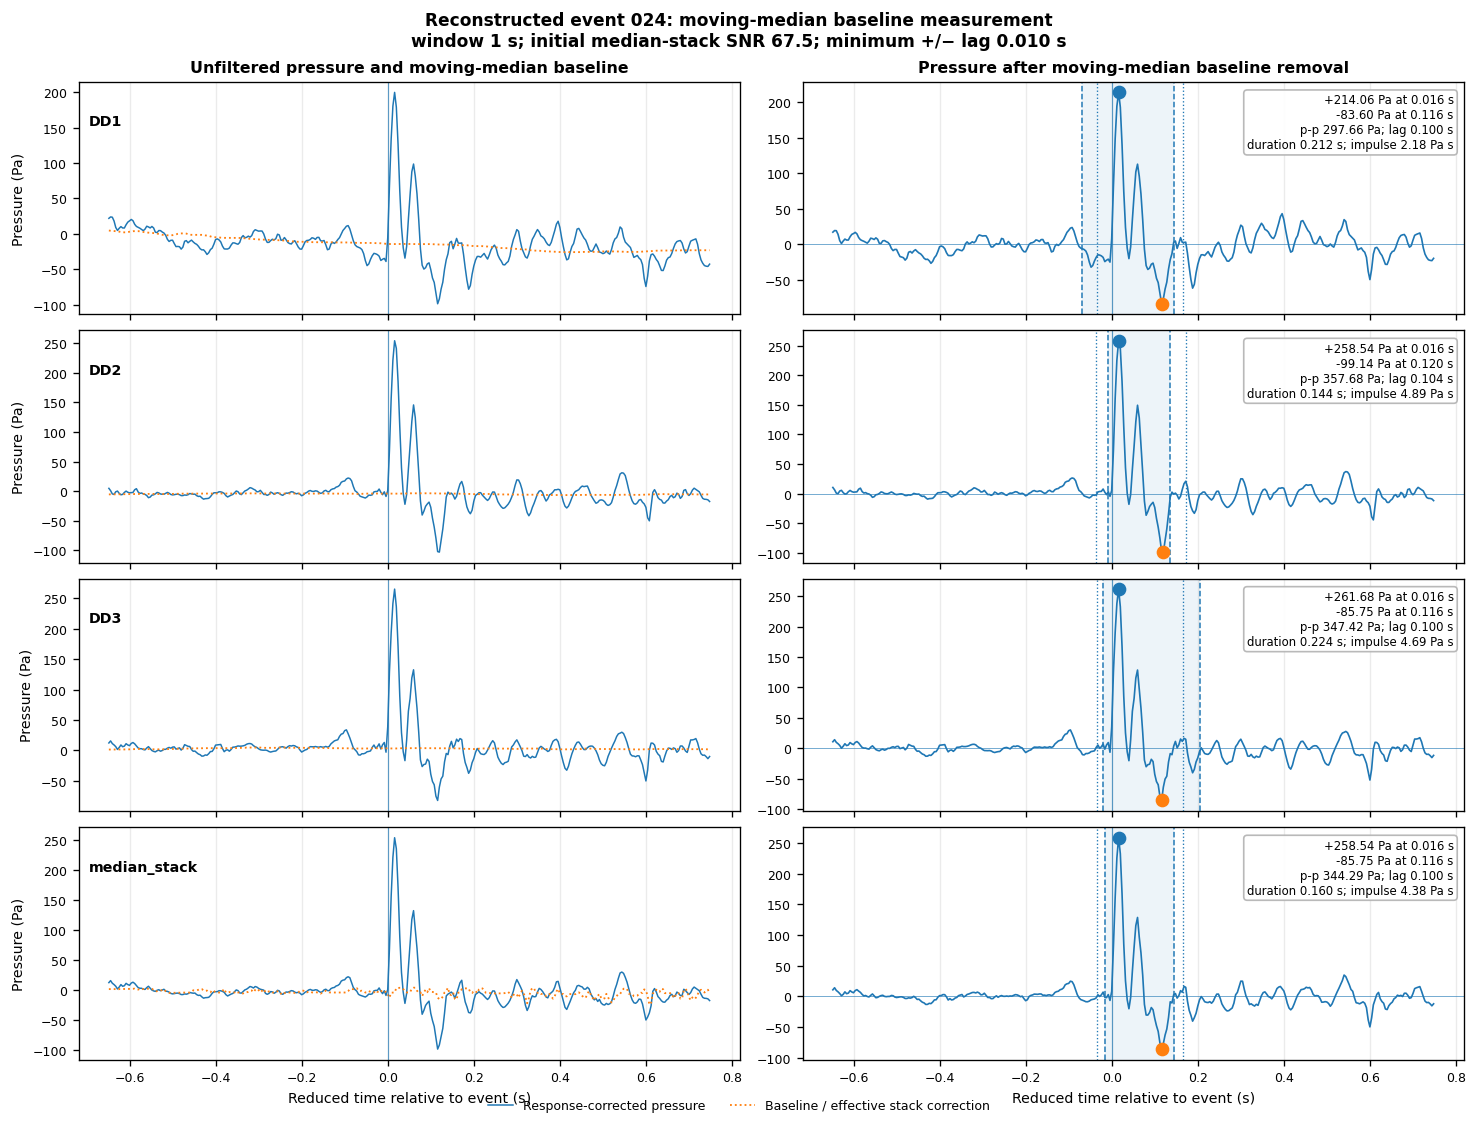

In [21]:
PREVIEW_EVENT_NUMBER = int(
    selected_events.iloc[0][
        "reconstructed_event_number"
    ]
)

preview_figure = build_event_diagnostic_figure(
    PREVIEW_EVENT_NUMBER
)
plt.show()

## 19. Cross-channel consistency and lag checks

In [22]:
valid_channel_measurements = (
    moving_median_measurements.loc[
        moving_median_measurements[
            "waveform_type"
        ].isin(INFRASOUND_CHANNELS)
        & moving_median_measurements[
            "valid_measurement"
        ]
    ]
    .copy()
)

event_consistency = (
    valid_channel_measurements
    .groupby("reconstructed_event_number")
    .agg(
        channel_count=("waveform_type", "nunique"),
        median_positive_peak_pa=(
            "positive_peak_pa",
            "median",
        ),
        median_negative_peak_pa=(
            "negative_peak_pa",
            "median",
        ),
        median_peak_to_peak_pa=(
            "peak_to_peak_pa",
            "median",
        ),
        positive_time_range_s=(
            "positive_time_s",
            lambda x: x.max() - x.min(),
        ),
        negative_time_range_s=(
            "negative_time_s",
            lambda x: x.max() - x.min(),
        ),
        median_lag_s=(
            "positive_negative_lag_s",
            "median",
        ),
        lag_range_s=(
            "positive_negative_lag_s",
            lambda x: x.max() - x.min(),
        ),
        median_duration_s=(
            "event_duration_s",
            "median",
        ),
    )
    .reset_index()
)

display(event_consistency)

event_consistency.to_csv(
    DERIVED_OUTPUT_DIR
    / "moving_median_cross_channel_consistency.csv",
    index=False,
)

,reconstructed_event_number,channel_count,median_positive_peak_pa,median_negative_peak_pa,median_peak_to_peak_pa,positive_time_range_s,negative_time_range_s,median_lag_s,lag_range_s,median_duration_s
0,1,3,37.563647,-20.131315,57.882346,0.004,0.012,0.084,0.016,0.144
1,9,3,106.597316,-77.313855,173.473609,0.000,0.004,0.028,0.004,0.072
2,14,3,314.010150,-103.553143,417.432827,0.000,0.000,0.144,0.000,0.336
3,15,3,317.957677,-129.047375,447.005052,0.000,0.016,0.152,0.016,0.180
4,18,3,192.558872,-47.490866,240.374667,0.004,0.000,0.028,0.004,0.080
5,22,3,268.460641,-104.666444,384.738981,0.004,0.004,0.044,0.000,0.116
6,23,3,292.641617,-114.004646,406.646263,0.004,0.004,0.112,0.000,0.176
7,24,3,258.539812,-85.747104,347.422419,0.000,0.004,0.100,0.004,0.212
8,25,3,96.566906,-98.659205,194.332181,0.004,0.004,0.036,0.000,0.120
9,32,3,47.529586,-12.624586,60.382524,0.004,0.084,0.052,0.084,0.176


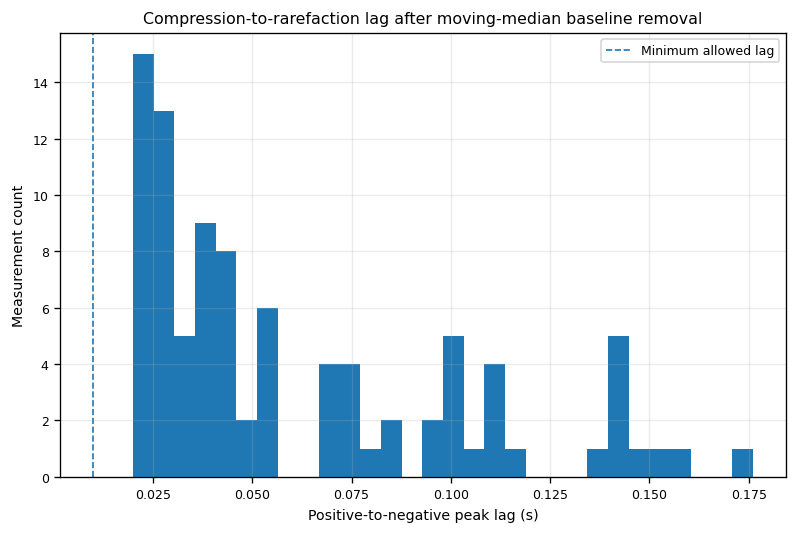

In [23]:
fig, ax = plt.subplots(figsize=(7.8, 4.8))
ax.hist(
    moving_median_measurements.loc[
        moving_median_measurements[
            "valid_measurement"
        ],
        "positive_negative_lag_s",
    ],
    bins=30,
)
ax.axvline(
    MINIMUM_POSITIVE_NEGATIVE_LAG_S,
    linestyle="--",
    linewidth=1.0,
    label="Minimum allowed lag",
)
ax.set_xlabel(
    "Positive-to-negative peak lag (s)"
)
ax.set_ylabel("Measurement count")
ax.set_title(
    "Compression-to-rarefaction lag after "
    "moving-median baseline removal"
)
ax.grid(True, alpha=0.25)
ax.legend()

lag_figure = (
    SUMMARY_PLOT_DIR
    / "positive_negative_lag_histogram.pdf"
)
fig.savefig(
    lag_figure,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Moving-median window-length sensitivity

This experiment recomputes the moving-median baseline for selected events
using 0.125, 0.25, 0.5, 1.0, and 2.0 s windows. Each baseline is computed
on the full trace before extracting, aligning and stacking the channels.
The aligned-stack difference is an effective correction, not a moving median
applied to the raw stack. Fixed search-window pressure-squared integrals
are also exported, independently of adaptive pulse-pair boundaries. It compares how much the measured
peak-to-peak pressure and baseline vary with window length.

The preferred window should lie on a stability plateau. A window is too
short when it follows and partially removes the pulse; it is unnecessarily
long when it fails to track genuine baseline variation.

In [24]:
# Compute each candidate baseline on complete traces, before alignment/stacking.
sensitivity_streams = {}
for window_s in MOVING_MEDIAN_TEST_WINDOWS_S:
    if window_s == MOVING_MEDIAN_WINDOW_S:
        sensitivity_streams[window_s] = st_corr_median_removed.copy()
    else:
        corrected_stream = Stream()
        for trace in st_corr:
            corrected_stream += (remove_moving_median_baseline(trace, window_s=window_s)[0]
                                 if trace.stats.channel in INFRASOUND_CHANNELS else trace.copy())
        sensitivity_streams[window_s] = corrected_stream
    print(f"Prepared whole-stream baseline: {window_s:g} s", flush=True)

window_sensitivity_rows = []
window_sensitivity_cache = {}
for event in selected_events.itertuples(index=False):
    event_number = int(event.reconstructed_event_number)
    times_s, raw_arrays, sampling_rate_hz = extract_shifted_event_arrays(float(event.reduced_event_epoch_s), stream=st_corr)
    raw_with_stack = {**raw_arrays, "median_stack": np.median(np.vstack(list(raw_arrays.values())), axis=0)}
    for window_s, corrected_stream in sensitivity_streams.items():
        corrected_times, arrays, _ = extract_shifted_event_arrays(float(event.reduced_event_epoch_s), stream=corrected_stream)
        if not np.allclose(times_s, corrected_times, atol=1e-9, rtol=0):
            raise ValueError("Sensitivity sample grids differ")
        arrays["median_stack"] = np.median(np.vstack(list(arrays.values())), axis=0)
        for waveform_type, corrected in arrays.items():
            result = measure_moving_median_event(corrected, times_s)
            fixed = (times_s >= SIGNAL_SEARCH_WINDOW_S[0]) & (times_s <= SIGNAL_SEARCH_WINDOW_S[1])
            exposure = float(np.trapezoid(corrected[fixed]**2, times_s[fixed]))
            window_sensitivity_rows.append({
                "final_event_number": int(event.final_event_number),
                "reconstructed_event_number": event_number,
                "waveform_type": waveform_type,
                "moving_median_window_s": window_s,
                "fixed_window_pressure_squared_pa2_s": exposure,
                **result,
            })
            window_sensitivity_cache[(event_number, waveform_type, window_s)] = {
                "times_s": times_s, "raw_values": raw_with_stack[waveform_type],
                "baseline": raw_with_stack[waveform_type] - corrected,
                "corrected_values": corrected, **result,
            }
window_sensitivity = pd.DataFrame(
    window_sensitivity_rows
)

window_sensitivity.to_csv(
    DERIVED_OUTPUT_DIR
    / "moving_median_window_sensitivity.csv",
    index=False,
)

display(
    window_sensitivity.loc[
        window_sensitivity["waveform_type"]
        == "median_stack"
    ]
    .groupby("moving_median_window_s")
    .agg(
        valid_fraction=("valid_measurement", "mean"),
        median_positive_peak_pa=("positive_peak_pa", "median"),
        median_negative_peak_pa=("negative_peak_pa", "median"),
        median_peak_to_peak_pa=("peak_to_peak_pa", "median"),
        median_lag_s=("positive_negative_lag_s", "median"),
        median_duration_s=("event_duration_s", "median"),
    )
)

# Paired comparisons avoid changing the valid-event population across windows.
reference = window_sensitivity.loc[window_sensitivity.moving_median_window_s.eq(MOVING_MEDIAN_WINDOW_S)].set_index(["reconstructed_event_number", "waveform_type"])
paired = window_sensitivity.merge(reference[["valid_measurement", "peak_to_peak_pa", "positive_time_s", "negative_time_s"]].add_prefix("adopted_"), left_on=["reconstructed_event_number", "waveform_type"], right_index=True, validate="many_to_one")
paired["both_valid"] = paired.valid_measurement & paired.adopted_valid_measurement
paired["peak_to_peak_ratio_to_adopted"] = np.where(paired.both_valid, paired.peak_to_peak_pa / paired.adopted_peak_to_peak_pa, np.nan)
paired["positive_time_change_s"] = np.where(paired.both_valid, paired.positive_time_s - paired.adopted_positive_time_s, np.nan)
paired["negative_time_change_s"] = np.where(paired.both_valid, paired.negative_time_s - paired.adopted_negative_time_s, np.nan)
paired.to_csv(DERIVED_OUTPUT_DIR / "moving_median_paired_window_sensitivity.csv", index=False)


Prepared whole-stream baseline: 0.125 s
Prepared whole-stream baseline: 0.25 s
Prepared whole-stream baseline: 0.5 s
Prepared whole-stream baseline: 1 s
Prepared whole-stream baseline: 2 s


,valid_fraction,median_positive_peak_pa,median_negative_peak_pa,median_peak_to_peak_pa,median_lag_s,median_duration_s
moving_median_window_s,,,,,,
0.125,1.000000,75.511353,-33.738424,102.228088,0.038,0.134
0.250,1.000000,74.835729,-35.585414,104.066842,0.042,0.144
0.500,1.000000,73.772653,-28.401799,107.390236,0.044,0.152
1.000,0.958333,69.812894,-33.779341,90.042027,0.044,0.140
2.000,0.958333,68.919341,-28.659891,90.192045,0.044,0.152


In [25]:
def build_window_sensitivity_figure(
    event_number: int,
    waveform_type: str = "median_stack",
):
    windows = list(MOVING_MEDIAN_TEST_WINDOWS_S)

    fig, axes = plt.subplots(
        len(windows),
        2,
        figsize=(11.5, 2.5 * len(windows)),
        sharex=True,
        constrained_layout=True,
    )

    for row_index, window_s in enumerate(windows):
        cached = window_sensitivity_cache[
            (event_number, waveform_type, window_s)
        ]

        raw_axis = axes[row_index, 0]
        corrected_axis = axes[row_index, 1]

        raw_axis.plot(
            cached["times_s"],
            cached["raw_values"],
            linewidth=0.9,
            label="Raw",
        )
        raw_axis.plot(
            cached["times_s"],
            cached["baseline"],
            linestyle=":",
            linewidth=1.1,
            label="Baseline / effective stack correction",
        )
        raw_axis.text(
            0.015,
            0.84,
            f"{window_s:g} s window",
            transform=raw_axis.transAxes,
            fontweight="bold",
            va="top",
        )
        raw_axis.grid(True, axis="x", alpha=0.25)

        corrected_axis.plot(
            cached["times_s"],
            cached["corrected_values"],
            linewidth=1.0,
        )
        corrected_axis.axhline(
            0.0,
            linewidth=0.55,
            alpha=0.55,
        )
        corrected_axis.grid(
            True,
            axis="x",
            alpha=0.25,
        )

        if cached["valid_measurement"]:
            corrected_axis.scatter(
                [cached["positive_time_s"]],
                [cached["positive_peak_pa"]],
                s=44,
                zorder=6,
            )
            corrected_axis.scatter(
                [cached["negative_time_s"]],
                [cached["negative_peak_pa"]],
                s=44,
                zorder=6,
            )
            corrected_axis.set_title(
                f"p-p {cached['peak_to_peak_pa']:.2f} Pa; "
                f"lag {cached['positive_negative_lag_s']:.3f} s"
            )

    axes[0, 0].set_title(
        "Raw waveform and candidate baseline",
        fontweight="bold",
    )
    axes[-1, 0].set_xlabel(
        "Reduced time relative to event (s)"
    )
    axes[-1, 1].set_xlabel(
        "Reduced time relative to event (s)"
    )

    fig.suptitle(
        f"Event {event_number:03d}: "
        f"moving-median window sensitivity ({waveform_type})",
        fontweight="bold",
    )

    return fig

In [26]:
WINDOW_SENSITIVITY_DIR = (
    OUTPUT_DIR / "window_sensitivity"
)
WINDOW_SENSITIVITY_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

for event_number in selected_events[
    "reconstructed_event_number"
].astype(int):
    figure = build_window_sensitivity_figure(
        event_number,
        waveform_type="median_stack",
    )
    outfile = (
        WINDOW_SENSITIVITY_DIR
        / f"event_{event_number:03d}_window_sensitivity.pdf"
    )
    figure.savefig(
        outfile,
        dpi=220,
        bbox_inches="tight",
    )
    plt.close(figure)

print(
    f"Wrote sensitivity figures to "
    f"{WINDOW_SENSITIVITY_DIR}"
)

Wrote sensitivity figures to /Users/glennthompson/Developer/KSCRocketSeismoHydrology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/060_validate_infrasound_baseline_correction/window_sensitivity


## Principal-explosion fixed-window energy sensitivity
For fixed geometry, density and sound speed, energy ratios equal ratios of
channel pressure-squared integrals. No additional high-pass or fitted local
baseline is applied here. The reused reviewed signal bounds must be checked
against the later 110/120 named-event processing before revising manuscript energies.


,channel,moving_median_window_s,reference_start_epoch_s,reference_end_epoch_s,sampled_start_epoch_s,sampled_end_epoch_s,pressure_squared_pa2_s,positive_peak_pa,negative_peak_pa,energy_ratio_to_adopted
0,DD1,0.125,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,15462.560128,928.257429,-148.374740,0.257930
1,DD2,0.125,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,20236.581950,1071.553517,-181.830596,0.248305
2,DD3,0.125,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,17964.636905,969.944335,-176.344065,0.253304
3,DD1,0.250,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,28833.173932,1099.055477,-147.967943,0.480965
4,DD2,0.250,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,38177.610909,1251.278171,-160.294511,0.468443
5,DD3,0.250,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,31502.645510,1128.854389,-161.353175,0.444192
6,DD1,0.500,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,44790.733133,1224.662175,-147.295431,0.747152
7,DD2,0.500,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,61190.930401,1423.832697,-158.805055,0.750819
8,DD3,0.500,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,52459.763662,1301.978069,-165.750942,0.739691
9,DD1,1.000,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,59948.604682,1301.957262,-137.964291,1.000000


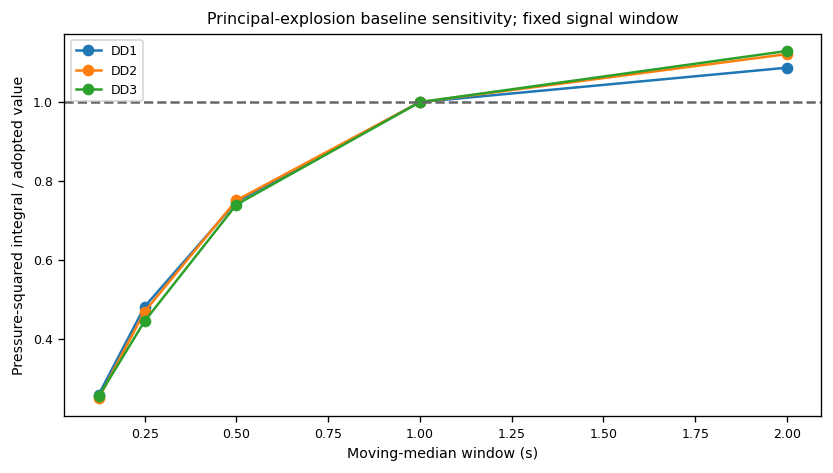

955

In [27]:
# Principal signal interval: Notebook 110's reviewed -1.45-s extraction offset
# plus signal bounds 0.75 to 2.50 s. Source time always comes from config.
PRINCIPAL_SIGNAL_OFFSETS_S = (-0.70, 1.05)
principal_reference_epoch = float(config.source_event_time("lower_stage").timestamp) + BCHH_INFRASOUND_DISTANCES_M[REFERENCE_CHANNEL] / 351.0
principal_rows = []
for window_s, corrected_stream in sensitivity_streams.items():
    for channel in INFRASOUND_CHANNELS:
        trace = select_one_trace(corrected_stream, channel)
        start = principal_reference_epoch + DIFFERENTIAL_DELAYS_S[channel] + PRINCIPAL_SIGNAL_OFFSETS_S[0]
        end = principal_reference_epoch + DIFFERENTIAL_DELAYS_S[channel] + PRINCIPAL_SIGNAL_OFFSETS_S[1]
        first = int(np.ceil((start - float(trace.stats.starttime.timestamp)) * trace.stats.sampling_rate))
        last = int(np.floor((end - float(trace.stats.starttime.timestamp)) * trace.stats.sampling_rate))
        if first < 0 or last >= trace.stats.npts or last <= first:
            raise ValueError("Principal window exceeds coverage")
        values = np.asarray(trace.data[first:last+1], dtype=float)
        exposure = float(np.trapezoid(values**2, dx=1.0/trace.stats.sampling_rate))
        principal_rows.append({"channel": channel, "moving_median_window_s": window_s,
            "reference_start_epoch_s": principal_reference_epoch + PRINCIPAL_SIGNAL_OFFSETS_S[0],
            "reference_end_epoch_s": principal_reference_epoch + PRINCIPAL_SIGNAL_OFFSETS_S[1],
            "sampled_start_epoch_s": float(trace.stats.starttime.timestamp) + first/trace.stats.sampling_rate,
            "sampled_end_epoch_s": float(trace.stats.starttime.timestamp) + last/trace.stats.sampling_rate,
            "pressure_squared_pa2_s": exposure, "positive_peak_pa": float(values.max()),
            "negative_peak_pa": float(values.min())})
principal_sensitivity = pd.DataFrame(principal_rows)
reference_exposure = principal_sensitivity.loc[principal_sensitivity.moving_median_window_s.eq(MOVING_MEDIAN_WINDOW_S)].set_index("channel").pressure_squared_pa2_s
principal_sensitivity["energy_ratio_to_adopted"] = principal_sensitivity.pressure_squared_pa2_s / principal_sensitivity.channel.map(reference_exposure)
principal_sensitivity.to_csv(DERIVED_OUTPUT_DIR / "principal_baseline_energy_sensitivity.csv", index=False)
display(principal_sensitivity)
fig, ax = plt.subplots(figsize=(7, 4))
for channel, rows in principal_sensitivity.groupby("channel"):
    ax.plot(rows.moving_median_window_s, rows.energy_ratio_to_adopted, "o-", label=channel)
ax.axhline(1, color="0.4", ls="--")
ax.set(xlabel="Moving-median window (s)", ylabel="Pressure-squared integral / adopted value",
       title="Principal-explosion baseline sensitivity; fixed signal window")
ax.legend(); fig.tight_layout()
fig.savefig(SUMMARY_PLOT_DIR / "principal_baseline_energy_sensitivity.pdf")
plt.show()
(DERIVED_OUTPUT_DIR / "baseline_sensitivity_processing.json").write_text(json.dumps({
    "notebook": "060_validate_infrasound_baseline_correction.ipynb",
    "processing_order": "whole-trace channel baseline subtraction, then extraction/alignment/stacking",
    "test_windows_s": list(MOVING_MEDIAN_TEST_WINDOWS_S),
    "selected_final_events": selected_events.final_event_number.astype(int).tolist(),
    "fixed_selected_window_s": list(SIGNAL_SEARCH_WINDOW_S),
    "principal_source_key": "lower_stage", "principal_signal_offsets_s": list(PRINCIPAL_SIGNAL_OFFSETS_S),
    "principal_window_provenance": "Notebook 110 manually reviewed extraction/signal offsets; exploratory reuse",
    "source_reduction_speed_mps": 351.0,
    "differential_speed_mps": WIND_CORRECTED_ACOUSTIC_SPEED_MPS,
    "interpretation": "Pressure-squared sensitivity only; not a replacement for named-event radiated energy or its full uncertainty"
}, indent=2) + "\n")


## 20. Interpretation and quality control

The moving median is the adopted baseline model and is applied upstream in Notebook 010.
Before extending the measurements to the entire catalogue, visually inspect:

- whether the moving median passes through the slowly varying background rather
  than through the impulsive signal;
- whether a 1.0 s window is sufficiently long for the largest and broadest
  arrivals;
- whether the positive peak is followed by the physically associated negative
  peak rather than a later neighboring event;
- whether the 0.01 s minimum lag rejects high-frequency sample-to-sample
  fluctuations without excluding convincing short airwaves;
- whether noise-refined event boundaries are more plausible than the simple
  sinusoidal bounds;
- whether nearby events contaminate the inferred event interval.

A 1 Hz high-pass may later be used only as a **guide** for ambiguous weak events.
It is not applied to the pressure values measured here.